2.1 理论计算题
1. 无激活函数的隐藏层等价于单层网络
已知：

h = W1 * x + b1
o = W2 * h + b2

代入 h：

o = W2 * (W1 * x + b1) + b2
o = (W2 * W1) * x + (W2 * b1 + b2)

令：
W' = W2 * W1
b' = W2 * b1 + b2

则有：
o = W' * x + b'

等价于一个单层线性网络（无激活函数）。
结论：无激活函数的隐藏层不增加模型表达能力。

2. Sigmoid 与 tanh 的导数
Sigmoid
定义：
σ(x) = 1 / (1 + e^{-x})

导数推导：
σ'(x) = e^{-x} / (1 + e^{-x})^2

利用 e^{-x} = 1/σ(x) - 1 代入得：
σ'(x) = σ(x) * (1 - σ(x))

tanh
定义：
tanh(x) = (e^x - e^{-x}) / (e^x + e^{-x})

导数公式：
tanh'(x) = 1 - (tanh(x))^2

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. 加载 Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# 2. 手动初始化参数
input_size = 28 * 28
hidden_size = 256
output_size = 10

W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

# 需要梯度
W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

# 3. ReLU
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# 4. Softmax + CrossEntropy
def cross_entropy_softmax(logits, y):
    # logits: (batch, output_size)
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])  # 数值稳定
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    batch_size = logits.shape[0]
    loss = -torch.log(probs[range(batch_size), y] + 1e-8).mean()
    return loss

# 5. 训练循环
lr = 0.1
epochs = 5

for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        # 前向
        h = X @ W1 + b1
        h_relu = relu(h)
        logits = h_relu @ W2 + b2
        loss = cross_entropy_softmax(logits, y)

        # 反向（手动）
        loss.backward()

        # SGD 更新
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad

            # 清零梯度
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()

        total_loss += loss.item()

    # 测试准确率
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            h = X @ W1 + b1
            h_relu = relu(h)
            logits = h_relu @ W2 + b2
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Test Acc: {acc:.4f}")

Epoch 1, Loss: 0.6859, Test Acc: 0.7993
Epoch 2, Loss: 0.4488, Test Acc: 0.8313
Epoch 3, Loss: 0.3991, Test Acc: 0.8385
Epoch 4, Loss: 0.3704, Test Acc: 0.8568
Epoch 5, Loss: 0.3510, Test Acc: 0.8655


3.1 理论计算题
1. 过拟合与欠拟合
训练误差：模型在训练数据集上计算得到的损失。
泛化误差：模型在测试数据集上的损失。

当训练误差极低但泛化误差很高时，模型处于过拟合状态。

缓解方法：减少模型复杂度（减少层数/神经元数）、正则化（L1/L2/Dropout）、早停、增加数据。

2. K 折交叉验证步骤
将数据集随机打乱，均匀分成 K 份。

对 i = 1 到 K：

第 i 份作为验证集，其余 K-1 份作为训练集

训练模型并计算验证集上的性能指标

计算 K 次验证指标的平均值作为最终评估结果。

如需选超参数，选择平均性能最好的超参数后，用全部数据重训最终模型。

实验1: 无正则化（过拟合）
Epoch   0, Train Loss: 2.3035, Test Loss: 2.3012
Epoch  10, Train Loss: 2.2733, Test Loss: 2.2848
Epoch  20, Train Loss: 2.2196, Test Loss: 2.2533
Epoch  30, Train Loss: 2.1222, Test Loss: 2.1917
Epoch  40, Train Loss: 1.9809, Test Loss: 2.0844

实验2: 权重衰减 L2 (λ=0.01)
Epoch   0, Train Loss: 2.3544, Test Loss: 2.3014
Epoch  10, Train Loss: 2.3258, Test Loss: 2.2853
Epoch  20, Train Loss: 2.2709, Test Loss: 2.2521
Epoch  30, Train Loss: 2.1744, Test Loss: 2.1903
Epoch  40, Train Loss: 2.0493, Test Loss: 2.0987

实验3: Dropout (p=0.5)
Epoch   0, Train Loss: 2.3034, Test Loss: 2.3004
Epoch  10, Train Loss: 2.2701, Test Loss: 2.2826
Epoch  20, Train Loss: 2.2112, Test Loss: 2.2478
Epoch  30, Train Loss: 2.1122, Test Loss: 2.1815
Epoch  40, Train Loss: 1.9773, Test Loss: 2.0773


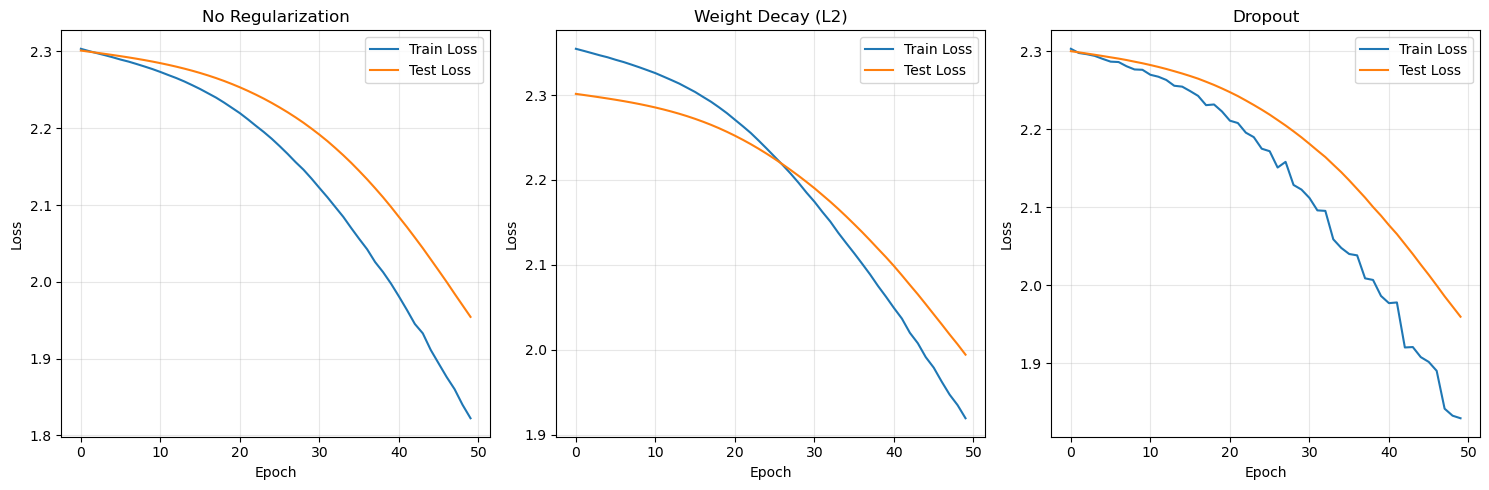


最终结果对比（Epoch 50）
无正则化:      Train = 1.8223, Test = 1.9543, Gap = -0.1320
权重衰减 L2:    Train = 1.9195, Test = 1.9943, Gap = -0.0749
Dropout:        Train = 1.8297, Test = 1.9599, Gap = -0.1302


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import gc

# 加载 Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_set_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 极少量样本制造过拟合（只用 100 张训练）
indices = list(range(100))
small_train_set = Subset(train_set_full, indices)
train_loader = DataLoader(small_train_set, batch_size=20, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

input_size = 28 * 28
hidden_size = 128
output_size = 10

def init_params():
    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    W1.requires_grad_(True)
    b1.requires_grad_(True)
    W2.requires_grad_(True)
    b2.requires_grad_(True)
    return W1, b1, W2, b2

def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def cross_entropy_softmax(logits, y):
    logits_max = torch.max(logits, dim=1, keepdim=True)[0]
    logits_shifted = logits - logits_max
    exp_logits = torch.exp(logits_shifted)
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    batch_size = logits.shape[0]
    loss = -torch.log(probs[range(batch_size), y] + 1e-8).mean()
    return loss

def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand_like(X) > dropout).float()
    return mask * X / (1.0 - dropout)

def train_model(use_weight_decay=False, weight_decay_lambda=0.0, use_dropout=False, dropout_rate=0.5, epochs=50):
    W1, b1, W2, b2 = init_params()
    lr = 0.01
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # 训练阶段
        total_train_loss = 0
        for X, y in train_loader:
            h = X @ W1 + b1
            h_relu = relu(h)
            if use_dropout:
                h_relu = dropout_layer(h_relu, dropout_rate, is_training=True)
            logits = h_relu @ W2 + b2
            loss = cross_entropy_softmax(logits, y)
            
            if use_weight_decay:
                l2_loss = 0.5 * weight_decay_lambda * (torch.sum(W1**2) + torch.sum(W2**2))
                loss = loss + l2_loss
            
            loss.backward()
            
            with torch.no_grad():
                if use_weight_decay:
                    W1 *= (1 - lr * weight_decay_lambda)
                    W2 *= (1 - lr * weight_decay_lambda)
                W1 -= lr * W1.grad
                b1 -= lr * b1.grad
                W2 -= lr * W2.grad
                b2 -= lr * b2.grad
                W1.grad.zero_()
                b1.grad.zero_()
                W2.grad.zero_()
                b2.grad.zero_()
            
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # 验证阶段
        total_test_loss = 0
        with torch.no_grad():
            for X, y in test_loader:
                h = X @ W1 + b1
                h_relu = relu(h)
                if use_dropout:
                    h_relu = dropout_layer(h_relu, dropout_rate, is_training=False)
                logits = h_relu @ W2 + b2
                loss = cross_entropy_softmax(logits, y)
                total_test_loss += loss.item()
        
        avg_test_loss = total_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
    
    return train_losses, test_losses

# 正式实验
results = {}

print("=" * 50)
print("实验1: 无正则化（过拟合）")
print("=" * 50)
results['no_reg'] = train_model(use_weight_decay=False, use_dropout=False, epochs=50)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "=" * 50)
print("实验2: 权重衰减 L2 (λ=0.01)")
print("=" * 50)
results['weight_decay'] = train_model(use_weight_decay=True, weight_decay_lambda=0.01, use_dropout=False, epochs=50)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "=" * 50)
print("实验3: Dropout (p=0.5)")
print("=" * 50)
results['dropout'] = train_model(use_dropout=True, dropout_rate=0.5, use_weight_decay=False, epochs=50)

# 绘制对比曲线
train_loss1, test_loss1 = results['no_reg']
train_loss2, test_loss2 = results['weight_decay']
train_loss3, test_loss3 = results['dropout']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_loss1, label='Train Loss', linewidth=1.5)
plt.plot(test_loss1, label='Test Loss', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('No Regularization')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(train_loss2, label='Train Loss', linewidth=1.5)
plt.plot(test_loss2, label='Test Loss', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Weight Decay (L2)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(train_loss3, label='Train Loss', linewidth=1.5)
plt.plot(test_loss3, label='Test Loss', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Dropout')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印最终结果
print("\n" + "=" * 50)
print("最终结果对比（Epoch 50）")
print("=" * 50)
print(f"无正则化:      Train = {train_loss1[-1]:.4f}, Test = {test_loss1[-1]:.4f}, Gap = {train_loss1[-1] - test_loss1[-1]:.4f}")
print(f"权重衰减 L2:    Train = {train_loss2[-1]:.4f}, Test = {test_loss2[-1]:.4f}, Gap = {train_loss2[-1] - test_loss2[-1]:.4f}")
print(f"Dropout:        Train = {train_loss3[-1]:.4f}, Test = {test_loss3[-1]:.4f}, Gap = {train_loss3[-1] - test_loss3[-1]:.4f}")

4.1 理论计算题
1. 梯度消失与梯度爆炸的量化分析
对于一个 d 层的深层神经网络，反向传播时第 t 层的梯度可以表示为：

∂L/∂h^t = (∂L/∂h^d) * ∏_{i=t}^{d-1} (∂h^{i+1}/∂h^i)

其中 ∂h^{i+1}/∂h^i = (∂σ/∂z^{i+1}) * W_{i+1}^T（忽略偏置），σ 是激活函数。

记 J_i = diag(σ'(z^{i+1})) * W_{i+1}^T，则梯度连乘项为 ∏ J_i。

梯度消失的条件：

当所有 W_i 的最大奇异值 < 1，且 σ'(z) 在大多数区域 < 1（如 Sigmoid 的导数最大值 0.25）

则 ∏ ||J_i|| 随层数指数衰减到 0，导致浅层梯度消失

梯度爆炸的条件：

当所有 W_i 的最大奇异值 > 1，且 σ'(z) 较大（如无界激活函数或特定初始化）

则 ∏ ||J_i|| 指数增长到无穷，导致梯度爆炸

量化关系：若每层 ‖J_i‖ ≈ α，则 ‖∏ J_i‖ ≈ α^{d-t}。α < 1 时消失，α > 1 时爆炸。

2. 为什么 ReLU 能缓解梯度消失
Sigmoid 的导数 σ'(x) ∈ (0, 0.25]，饱和区域接近 0，连乘时指数衰减到 0。

ReLU 的定义：f(x) = max(0, x)

导数：f'(x) = 1 当 x > 0，0 当 x < 0

当神经元激活（x > 0）时，梯度为 1，不回传衰减

梯度连乘项中至少一半左右神经元保持梯度为 1，不至于指数消失

不足：可能出现神经元死亡（x < 0 时永远不激活），但整体上比 Sigmoid 的全局饱和好得多。

In [2]:
import torch
import torch.nn as nn
import torch.nn.init as init

# 1. 构建深层网络
class DeepNet(nn.Module):
    def __init__(self, layers=20, width=256, activation='sigmoid', use_init=False, init_type='xavier'):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(layers):
            linear = nn.Linear(width if i > 0 else 784, width)
            if use_init:
                if init_type == 'xavier':
                    init.xavier_uniform_(linear.weight)
                elif init_type == 'normal':
                    init.normal_(linear.weight, mean=0, std=1)
            else:
                init.normal_(linear.weight, mean=0, std=1)
            init.zeros_(linear.bias)
            self.layers.append(linear)
            if activation == 'sigmoid':
                self.layers.append(nn.Sigmoid())
            elif activation == 'relu':
                self.layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                self.layers.append(nn.LeakyReLU(0.01))
        # 输出层
        self.output = nn.Linear(width, 10)
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.output(x)

def compute_gradient_norms(model, x, y):
    model.zero_grad()
    out = model(x)
    loss = nn.CrossEntropyLoss()(out, y)
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
            norms.append((name, torch.norm(param.grad).item()))
    return norms

batch_size = 64
x = torch.randn(batch_size, 784)
y = torch.randint(0, 10, (batch_size,))

# 2. Sigmoid + 普通高斯初始化 (std=1) — 梯度消失
print("=== Sigmoid + Normal init (std=1) ===")
model1 = DeepNet(layers=20, width=256, activation='sigmoid', use_init=False)
norms1 = compute_gradient_norms(model1, x, y)
for name, norm in norms1[:3] + norms1[-3:]:
    print(f"{name}: {norm:.2e}")

# 3. ReLU + 较大初始值 (std=10) — 梯度爆炸/NaN
print("\n=== ReLU + Large init (std=10) ===")
model2 = DeepNet(layers=20, width=256, activation='relu', use_init=True, init_type='normal')
for param in model2.parameters():
    if param.dim() >= 2:
        init.normal_(param, mean=0, std=10)
try:
    norms2 = compute_gradient_norms(model2, x, y)
    for name, norm in norms2[:3] + norms2[-3:]:
        print(f"{name}: {norm:.2e}")
except Exception as e:
    print(f"NaN or overflow occurred: {e}")

# 4. Xavier 初始化 + ReLU/LeakyReLU — 梯度稳定
print("\n=== Xavier init + LeakyReLU ===")
model3 = DeepNet(layers=20, width=256, activation='leaky_relu', use_init=True, init_type='xavier')
norms3 = compute_gradient_norms(model3, x, y)
for name, norm in norms3[:3] + norms3[-3:]:
    print(f"{name}: {norm:.2e}")

# 额外验证 Xavier + ReLU
print("\n=== Xavier init + ReLU ===")
model4 = DeepNet(layers=20, width=256, activation='relu', use_init=True, init_type='xavier')
norms4 = compute_gradient_norms(model4, x, y)
for name, norm in norms4[:3] + norms4[-3:]:
    print(f"{name}: {norm:.2e}")

=== Sigmoid + Normal init (std=1) ===
layers.0.weight: 3.94e+00
layers.2.weight: 2.00e+00
layers.4.weight: 1.54e+00
layers.36.weight: 6.30e-02
layers.38.weight: 4.60e-02
output.weight: 1.04e+00

=== ReLU + Large init (std=10) ===
layers.0.weight: nan
layers.2.weight: nan
layers.4.weight: nan
layers.36.weight: nan
layers.38.weight: nan
output.weight: nan

=== Xavier init + LeakyReLU ===
layers.0.weight: 1.59e-03
layers.2.weight: 1.09e-03
layers.4.weight: 1.15e-03
layers.36.weight: 1.11e-03
layers.38.weight: 1.03e-03
output.weight: 1.77e-03

=== Xavier init + ReLU ===
layers.0.weight: 1.53e-03
layers.2.weight: 1.10e-03
layers.4.weight: 1.09e-03
layers.36.weight: 9.38e-04
layers.38.weight: 9.74e-04
output.weight: 1.65e-03


5.1 理论计算题
协变量偏移与标签偏移的区别与联系
协变量偏移 (Covariate Shift)：
p(x) ≠ q(x) 但 p(y|x) = q(y|x)
即输入特征分布发生变化，但给定输入后输出的条件分布不变。

标签偏移 (Label Shift)：
p(y) ≠ q(y) 但 p(x|y) = q(x|y)
即输出标签分布发生变化，但给定标签后输入的分布不变。

实际生活例子
1. 医疗诊断（协变量偏移）

训练数据：来自三甲医院的病人，x 为检查指标（如血压、血糖），y 为是否患病

测试数据：来自社区医院的病人（人群更健康、年龄结构不同），p(x) 分布不同

但患病条件概率 p(y|x) 相同（因为病理机制一致）

偏移原因：人群分布改变，但医学规律不变

2. 电商推荐（标签偏移）

训练数据：去年用户购买记录，x 为用户浏览行为，y 为是否购买

测试数据：今年（受促销活动影响，购买率上升），p(y) 改变

但给定是否购买的情况下，用户浏览行为分布 p(x|y) 不变

偏移原因：用户购物意愿变化，但行为模式相似

3. 语音识别（协变量偏移）

训练数据：安静环境下录制的语音

测试数据：嘈杂环境下的语音（x 分布变化）

但同一个词到语音的映射 p(y|x) 不变

4. 金融风控（标签偏移）

训练数据：正常经济周期下的违约率

测试数据：经济衰退期（违约率升高），p(y) 变化

但给定是否违约，其消费行为模式 p(x|y) 变化不大

联系与区别
对比项	协变量偏移	标签偏移
变化的分布	p(x)	p(y)
不变的分布	p(y	x)	p(x	y)
典型场景	采样偏差、数据来源变化	类别比例变化、先验变化
校正方法	样本加权（重要性采样）	调整先验概率或重新加权
共同点：

都是训练集与测试集分布不一致

都可以通过样本加权或重新平衡来缓解

本质上都是 p(x,y) 的分解方式不同导致的偏移

Baseline MSE (without correction): 0.0102
Weighted MSE (with correction): 0.0240


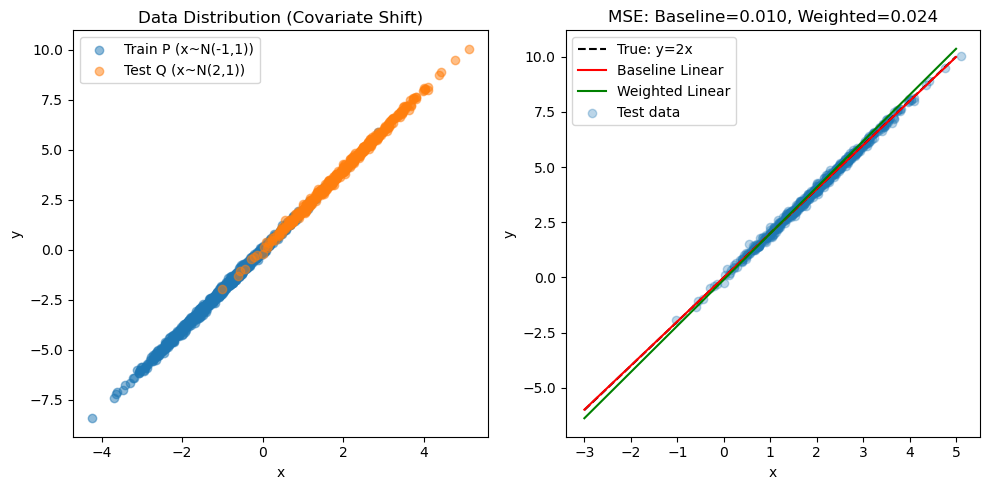

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# 1. 构造数据集
n_train = 1000
n_test = 500

# 训练集 P: x ~ N(-1, 1)
x_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
eps_train = np.random.normal(0, 0.1, n_train).reshape(-1, 1)
y_train = 2 * x_train + eps_train

# 测试集 Q: x ~ N(2, 1)
x_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
eps_test = np.random.normal(0, 0.1, n_test).reshape(-1, 1)
y_test = 2 * x_test + eps_test

# 2. 基线模型：直接在训练集上训练，测试集评估
baseline_model = LinearRegression()
baseline_model.fit(x_train, y_train)
y_pred_baseline = baseline_model.predict(x_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"Baseline MSE (without correction): {mse_baseline:.4f}")

# 3. 偏移校正：训练二分类器估计权重
# 将训练集标记为0，测试集标记为1
X_mixed = np.vstack([x_train, x_test])
y_mixed = np.vstack([np.zeros((n_train, 1)), np.ones((n_test, 1))]).ravel()

# 训练逻辑回归分类器
clf = LogisticRegression()
clf.fit(X_mixed, y_mixed)

# 预测每个样本属于测试集的概率 P(test|x)
prob_test_train = clf.predict_proba(x_train)[:, 1]  # P(test|x) for training samples
prob_test_test = clf.predict_proba(x_test)[:, 1]    # P(test|x) for test samples

# 计算权重 w_i = P(test|x_i) / P(train|x_i) = P(test|x_i) / (1 - P(test|x_i))
weights = prob_test_train / (1 - prob_test_train)

# 归一化权重（可选，不影响加权最小二乘）
weights = weights / weights.sum() * len(weights)

# 4. 加权线性回归
# 手工实现加权最小二乘法
X_train_with_intercept = np.hstack([np.ones((n_train, 1)), x_train])
W_diag = np.diag(weights)
theta_hat = np.linalg.inv(X_train_with_intercept.T @ W_diag @ X_train_with_intercept) @ X_train_with_intercept.T @ W_diag @ y_train

# 预测
X_test_with_intercept = np.hstack([np.ones((n_test, 1)), x_test])
y_pred_weighted = X_test_with_intercept @ theta_hat
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"Weighted MSE (with correction): {mse_weighted:.4f}")

# 5. 可视化对比
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, alpha=0.5, label='Train P (x~N(-1,1))')
plt.scatter(x_test, y_test, alpha=0.5, label='Test Q (x~N(2,1))')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Distribution (Covariate Shift)')
plt.legend()

plt.subplot(1, 2, 2)
x_plot = np.linspace(-3, 5, 100).reshape(-1, 1)
y_true = 2 * x_plot
y_baseline_plot = baseline_model.predict(x_plot)
X_plot_intercept = np.hstack([np.ones((100, 1)), x_plot])
y_weighted_plot = X_plot_intercept @ theta_hat
plt.plot(x_plot, y_true, 'k--', label='True: y=2x')
plt.plot(x_plot, y_baseline_plot, 'r-', label='Baseline Linear')
plt.plot(x_plot, y_weighted_plot, 'g-', label='Weighted Linear')
plt.scatter(x_test, y_test, alpha=0.3, label='Test data')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'MSE: Baseline={mse_baseline:.3f}, Weighted={mse_weighted:.3f}')
plt.legend()
plt.tight_layout()
plt.show()